# GBM analysis

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

## Read data

In [26]:
PATH_MODULES = "../datasets/module-predictions/"

In [27]:
samples_modules = dict()

In [28]:
for file_ in os.listdir(PATH_MODULES):
    if 'modules' in file_:
        data = pd.read_csv(PATH_MODULES + file_, sep = '\t')
        data = data[data['Coverage'] > 0.4]
        samples_modules[file_.split('.')[0]] = data
        # samples_modules[file_.split('.')[0]] = pd.read_csv(PATH_MODULES + file_, sep = '\t')

## Presence graph

In [29]:
gbm_metadata = pd.read_excel("../datasets/41564_2018_337_MOESM4_ESM.xlsx", sheet_name="Supplementary Table 10", skiprows = 1)

C:\Users\rafap\anaconda3\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [30]:
gbm_count = dict()

In [31]:
for gbm in list(gbm_metadata['Module.number']):
    gbm_count[gbm] = 0

In [32]:
for sample in samples_modules:
    for gbm in set(samples_modules[sample]['Module']):
        gbm_count[gbm] += 1

In [33]:
df = pd.DataFrame(list(gbm_count.items()), columns=['GBM', 'Count'])

In [34]:
df['Count'] = df['Count'] / len(samples_modules)

In [35]:
gbm_metadata.head()

,Module.number,Description,Label in Figure 3,Function,Structure,Pathway,Depression association reported,Depression association reference,Name_DB,Code,BBB.Prediction,BBB.Probability,Int.Prediction,Int.Probability,Unnamed: 14
0,MGB049,Tryptophan degradation,Trp deg,Amino acid,Amino acid,Tryptophan-derived,1,"PMID:2521647,11888576,11022402,26805875",L-Tryptophan,DB00150,+,0.9510,+,0.9840,* Predictions for each compound to cross the b...
1,MGB050,Glutamate degradation I,Glu deg I,Amino acid/ Neurotransmitter,Amino acid,Glutamate-derived,1,"PMID: 22731961,11986998,21827775",L-Glutamic Acid,DB00142,NaN,NaN,NaN,NaN,NaN
2,MGB051,Glutamate degradation II,Glu deg II,Amino acid/ Neurotransmitter,Amino acid,Glutamate-derived,1,"PMID: 22731961,11986998,21827775",L-Glutamic Acid,DB00142,NaN,NaN,NaN,NaN,NaN
3,MGB052,Butyrate synthesis I,Butyrate synt I,SCFA,SCFA,Butyrate,0,NaN,Isobutyric Acid,DB02531,+,0.9624,+,0.9848,NaN
4,MGB053,Butyrate synthesis II,Butyrate synt II,SCFA,SCFA,Butyrate,0,NaN,Isobutyric Acid,DB02531,+,0.9624,+,0.9848,NaN


In [36]:
labels = []
for gbm in list(df['GBM']):
    labels.append(gbm_metadata[gbm_metadata['Module.number'] == gbm]['Label in Figure 3'].iloc[0])

In [37]:
df['Labels'] = labels

In [38]:
df

,GBM,Count,Labels
0,MGB049,0.000000,Trp deg
1,MGB050,0.000000,Glu deg I
2,MGB051,0.063725,Glu deg II
3,MGB052,0.294118,Butyrate synt I
4,MGB053,0.107843,Butyrate synt II
5,MGB054,0.000000,Propionate synt II
6,MGB055,0.000000,Propionate synt III
7,MGB056,0.186275,Propionate deg I
8,MGB001,0.000000,Serotonin synt I
9,MGB002,0.000000,Serotonin synt II


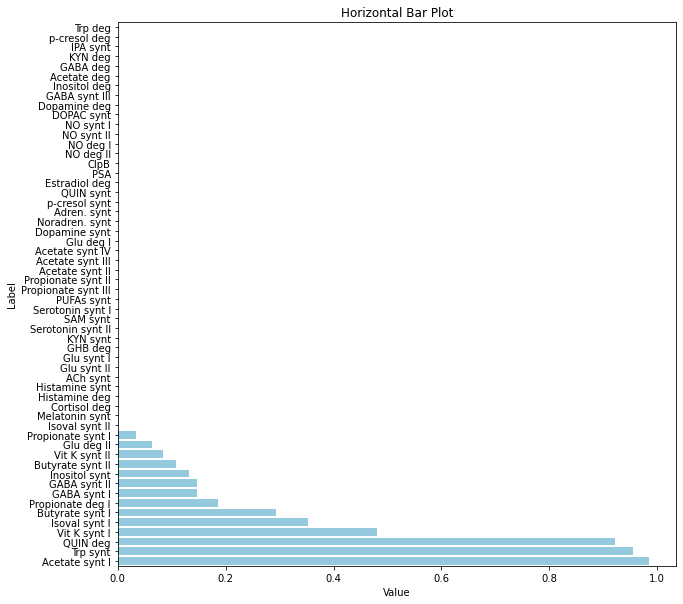

In [39]:
df = df.sort_values(by='Count', ascending=True)
plt.figure(figsize=(10, 10))  # Optional: Adjust the figure size
sns.barplot(data=df, y='Labels', x='Count', orient='h', color="skyblue")

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Label")
plt.title("Horizontal Bar Plot")

# Show the plot
plt.show()

## Rare GBMs (according to Valles-Colomer)

In [40]:
rare_gbms = [
    "Dopamine synt",
    "ACh synt",
    "Glu deg I",
    "Acetate synt II",
    "NO synt I",
    "Propionate synt III",
    "Butyrate synt II",
    "Serotonin synt II",
    "Histamine synt",
    "NO deg II",
    "KYN synt",
    "p-cresol deg",
    "Propionate synt I",
    "Glu deg II"
]

In [41]:
rare = df[(df['Labels'].isin(rare_gbms)) & (df['Count'] > 0)]

In [42]:
rare

,GBM,Count,Labels
55,MGB048,0.034314,Propionate synt I
2,MGB051,0.063725,Glu deg II
4,MGB053,0.107843,Butyrate synt II


In [43]:
species_gbm = dict()
for gbm in list(rare['GBM']):
    species_gbm[gbm] = set()
    for sample in samples_modules:
        if gbm in list(samples_modules[sample]['Module']):
            aux = samples_modules[sample][samples_modules[sample]['Module'] == gbm]
            for specie in aux['Taxon']:
                species_gbm[gbm].add(specie)
            
    

In [44]:
species_gbm

{'MGB048': {'Escherichia coli', 'Klebsiella pneumoniae'},
 'MGB051': {'CAG-170 sp000432135',
  'CAG-170 sp002404795',
  'Cetobacterium_A sp905216205',
  'Cetobacterium_A sp934085975',
  'Fusobacterium_A sp900555845',
  'Negativibacillus sp000435195',
  'PeH17 sp000435055'},
 'MGB053': {'Alistipes putredinis',
  'Anaerostipes hadrus',
  'Cetobacterium_A sp905216205',
  'Cetobacterium_A sp934085975',
  'Escherichia coli',
  'Fusobacterium_A sp900555845',
  'Limisoma sp000437795',
  'PeH17 sp000435055'}}

In [45]:
metadata = pd.read_excel('../datasets/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

rural_ids = list(metadata[metadata['Lifestyle'] == 'Rural']['Lane'])
urban_ids = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

In [46]:
present_gbms = list(df[df['Count'] > 0]['GBM'])

df2 = dict()
for sample in samples_modules:
    aux = []
    for gbm in present_gbms:
        if gbm in list(samples_modules[sample]['Module']):
            aux.append(1)
        else:
            aux.append(0)
    df2[sample] = aux


df3 = pd.DataFrame(df2,  index = present_gbms)

rural_gbms = df3[[x for x in rural_ids if x in df3.columns]]
urban_gbms = df3[[x for x in urban_ids if x in df3.columns]]

for gbm in df3.T.columns:
    print(gbm)
    r = sum(list(rural_gbms.T[gbm]))
    u = sum(list(urban_gbms.T[gbm]))
    print(r, u)

MGB048
6 1
MGB051
7 6
MGB041
0 17
MGB053
5 17
MGB037
7 20
MGB021
20 10
MGB020
22 8
MGB056
26 12
MGB052
25 35
MGB034
42 30
MGB040
57 41
MGB033
107 81
MGB005
111 84
MGB043
118 83


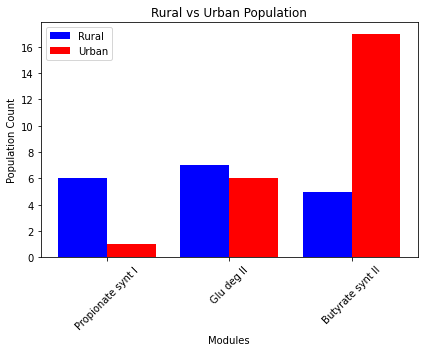

In [47]:
import numpy as np

# Updated Data with Labels
labels = ["Propionate synt I", "Glu deg II", "Butyrate synt II"]
rural = [6, 7, 5]
urban = [1, 6, 17]

x = np.arange(len(labels))  # Label positions
width = 0.4  # Bar width

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

# Plot bars
ax.bar(x - width/2, rural, width, label="Rural", color="blue")
ax.bar(x + width/2, urban, width, label="Urban", color="red")

# Labels and formatting
ax.set_xlabel("Modules")
ax.set_ylabel("Population Count")
ax.set_title("Rural vs Urban Population")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)  # Rotated for better visibility
ax.legend()

# Show plot
plt.tight_layout()
plt.show()
